Target: t1_n2o
Base features used: ['t1_nh4', 't1_no3', 'inflow', 't1_temp', 't1_ss', 't1_po4', 't1_airflow']

Prepared dataframe shape: (140771, 17)
Total modelling features: 15
Final feature list:
['t1_nh4', 't1_no3', 'inflow', 't1_temp', 't1_ss', 't1_po4', 't1_airflow', 't1_nh4_lag1', 't1_no3_lag1', 'inflow_lag1', 't1_temp_lag1', 't1_ss_lag1', 't1_po4_lag1', 't1_airflow_lag1', 't1_n2o_lag1']

Train shape     : (84462, 15) (84462,)
Validation shape: (28154, 15) (28154,)
Test shape      : (28155, 15) (28155,)

VALIDATION RESULTS FOR ALL MODELS
            model    segment     RMSE        R2
   Neural Network validation 0.007998  0.898137
Linear Regression validation 0.008405  0.887497
    Random Forest validation 0.056298 -4.047608

Best model on validation RMSE: Neural Network

TEST RESULTS FOR ALL MODELS
            model segment     RMSE       R2
    Random Forest    test 0.012180 0.994920
Linear Regression    test 0.012334 0.994790
   Neural Network    test 0.013901 0.993382

SUMM

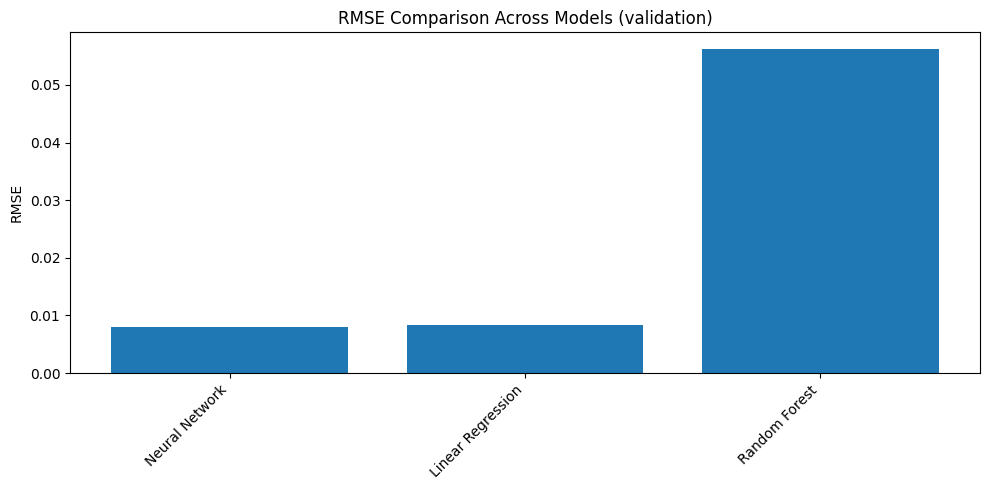

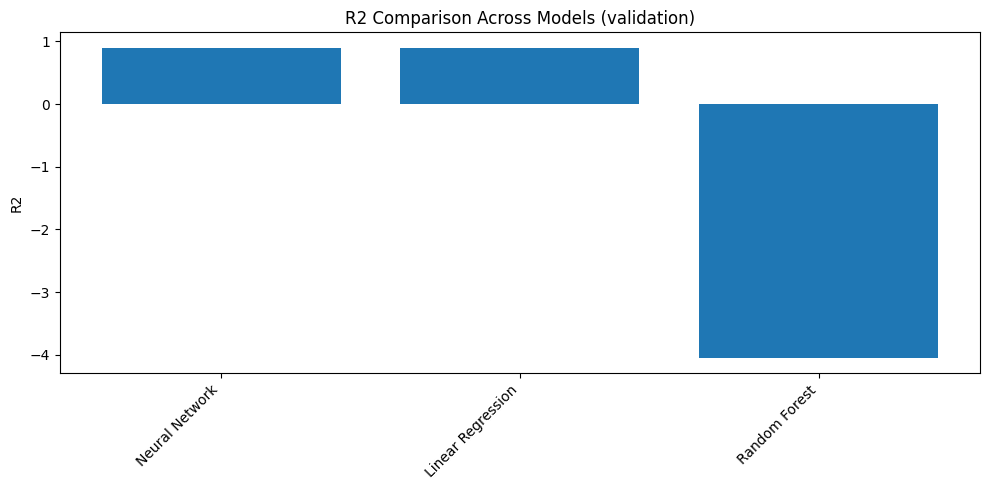

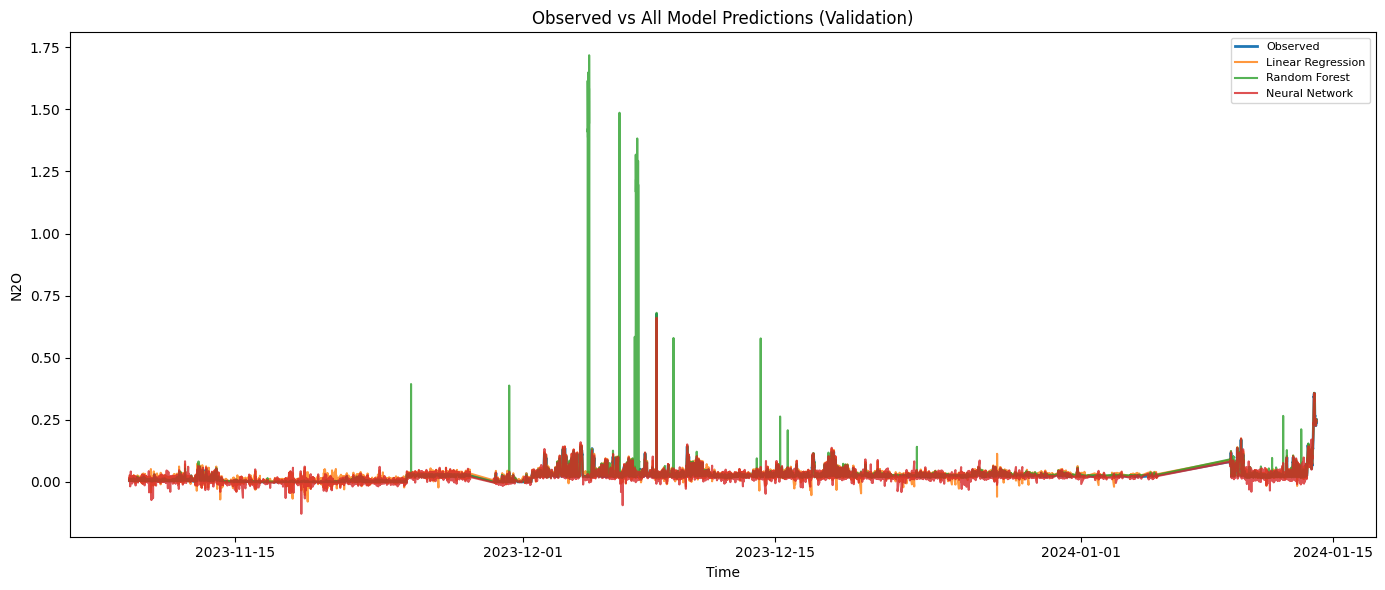

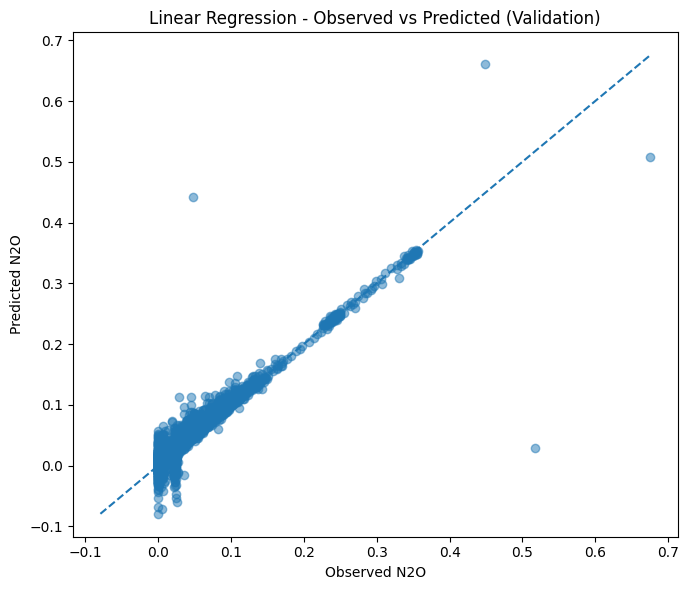

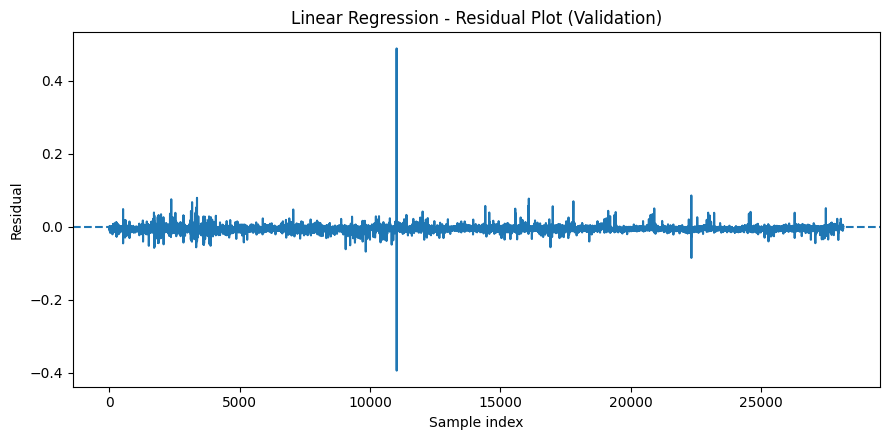

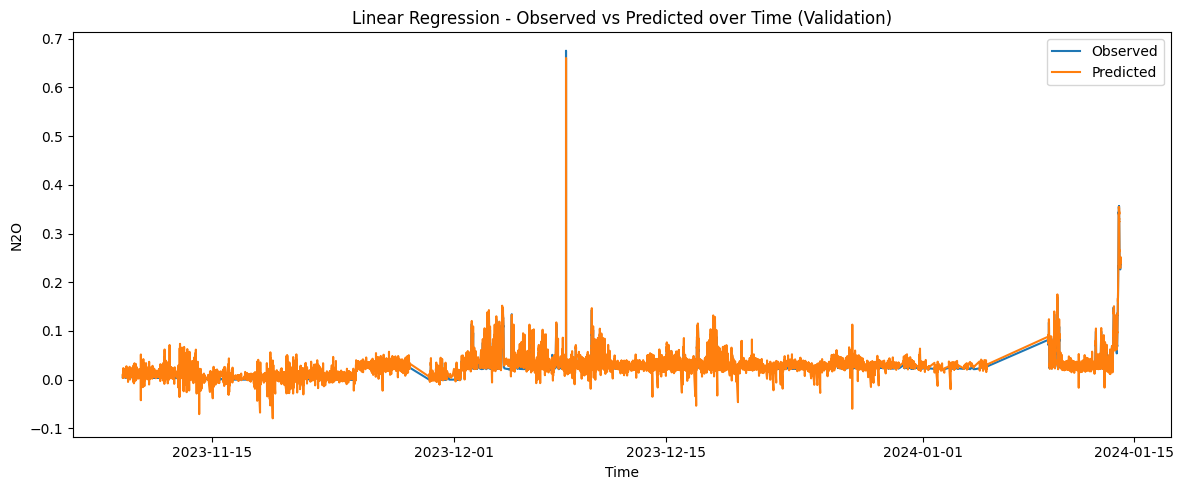

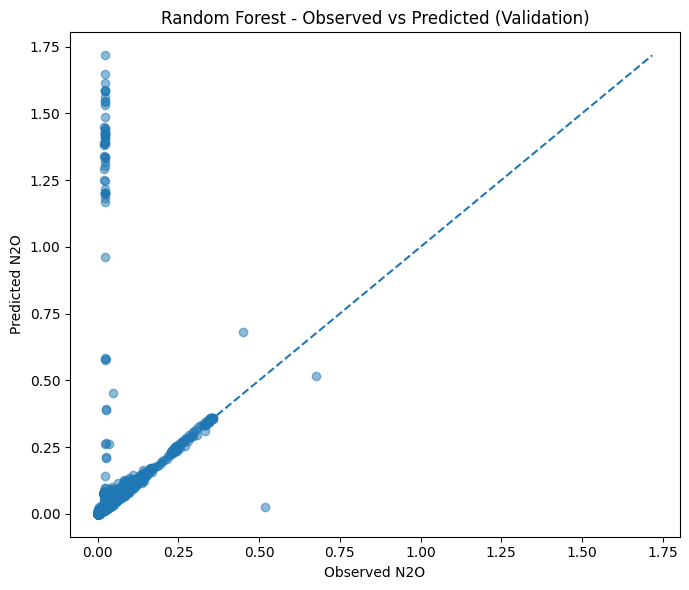

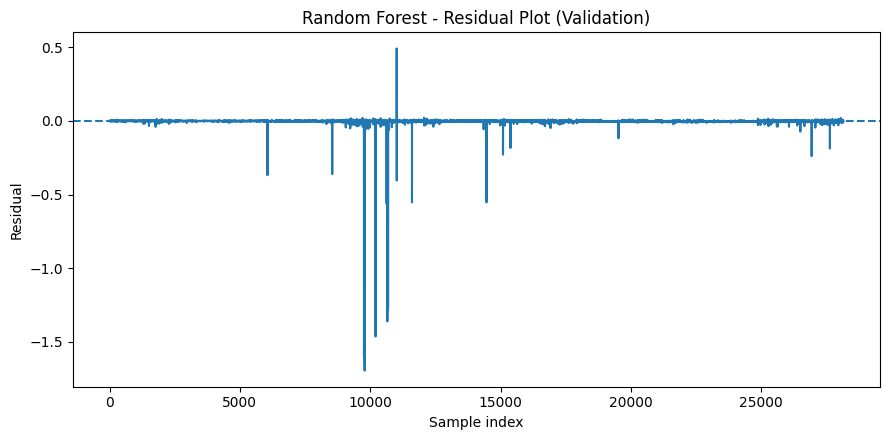

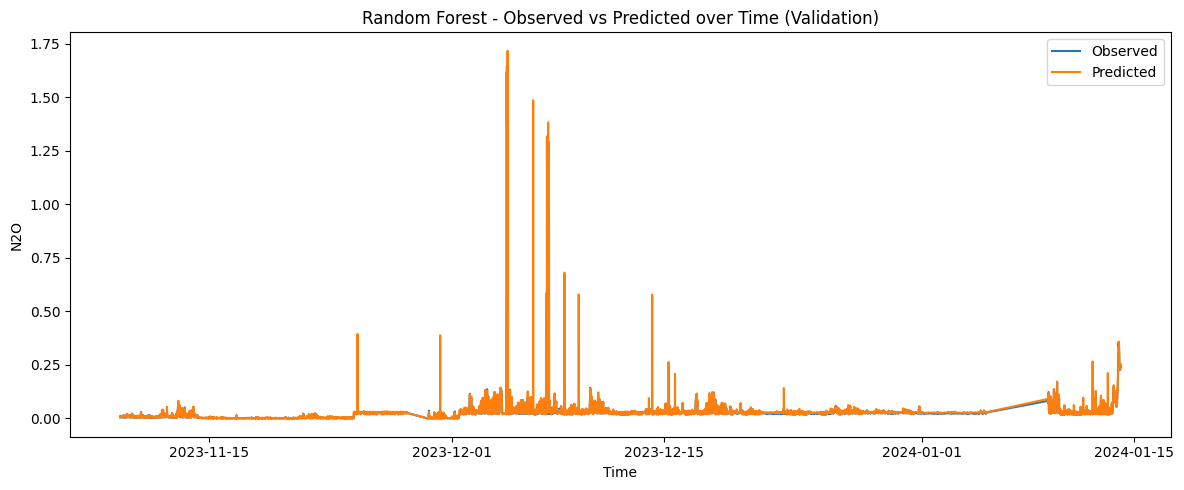

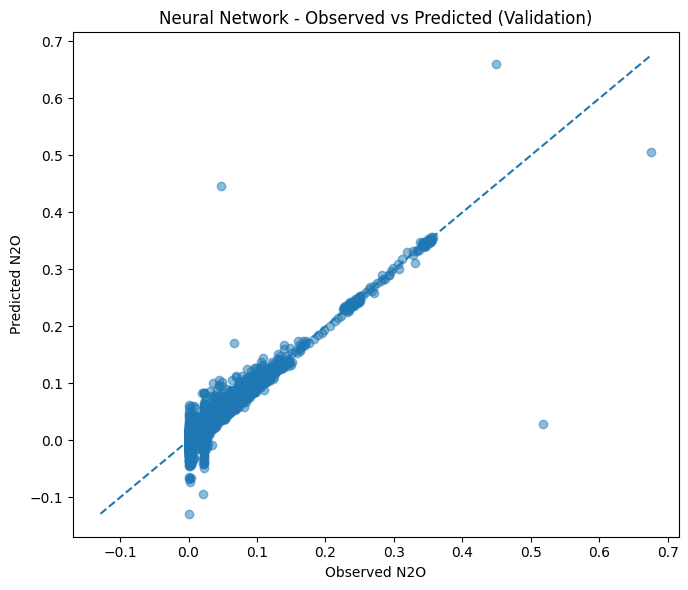

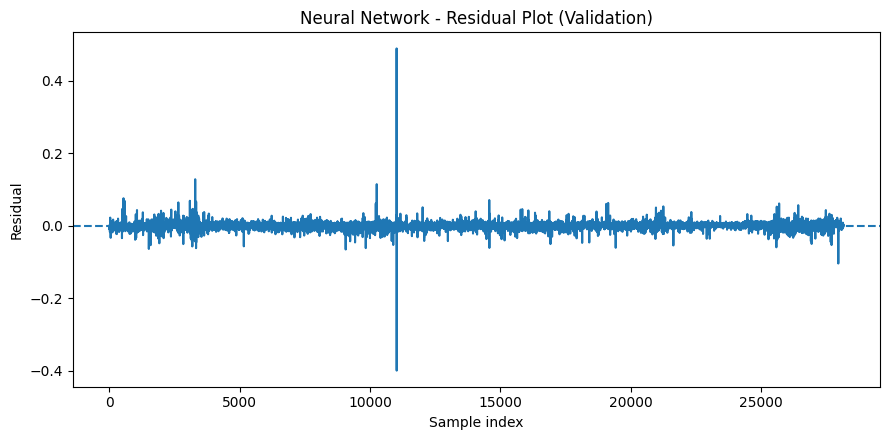

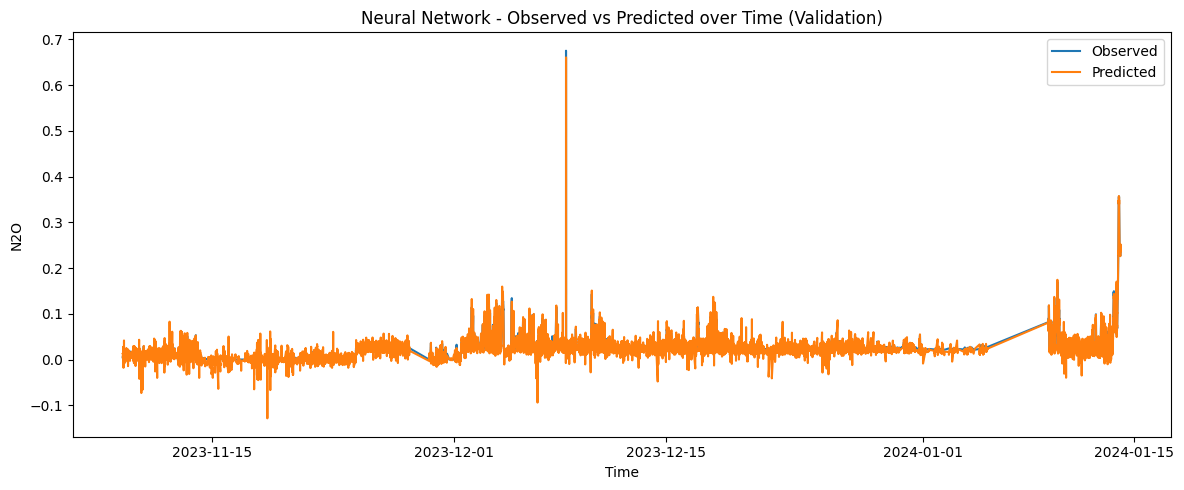

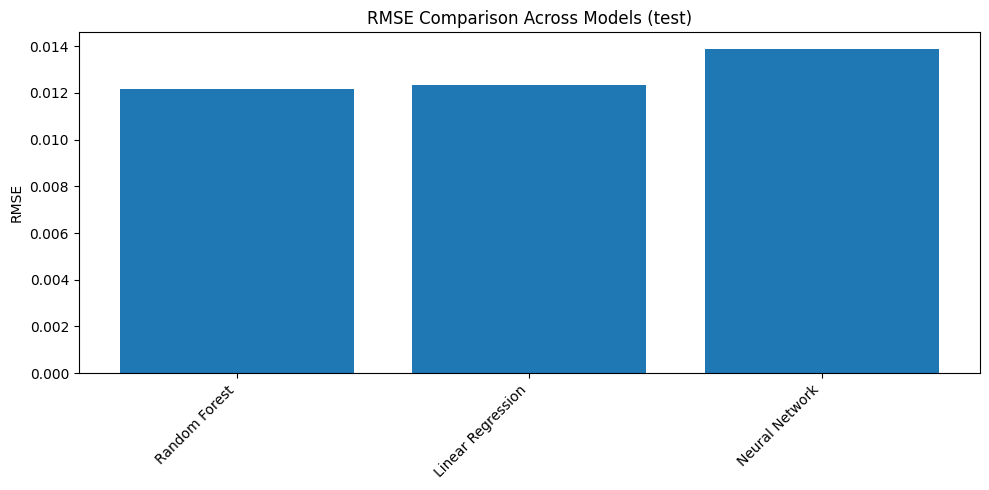

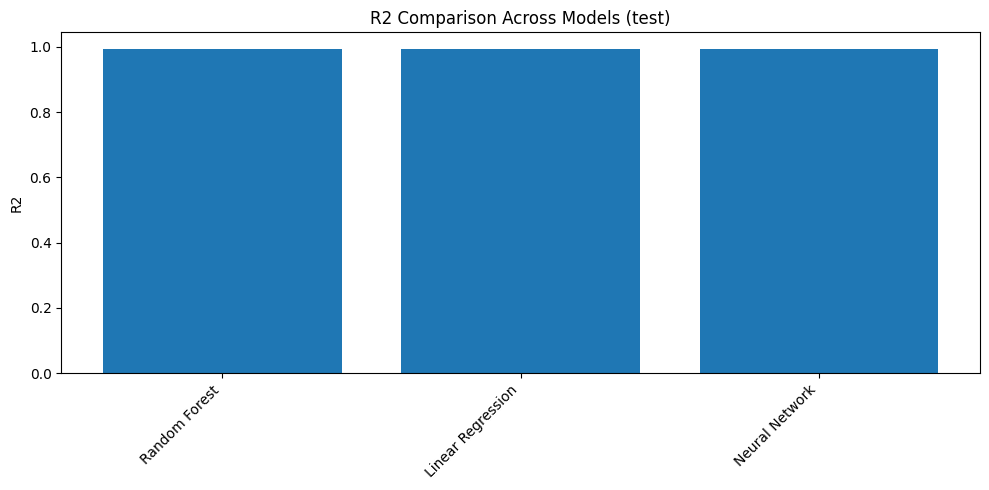

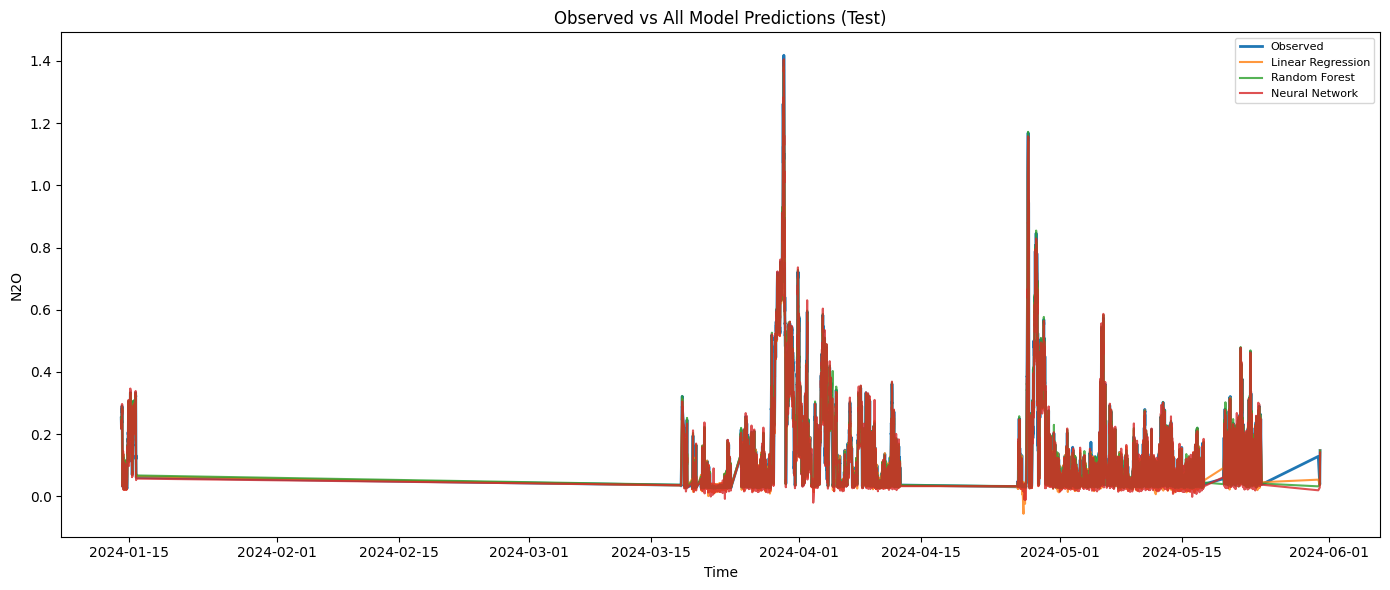

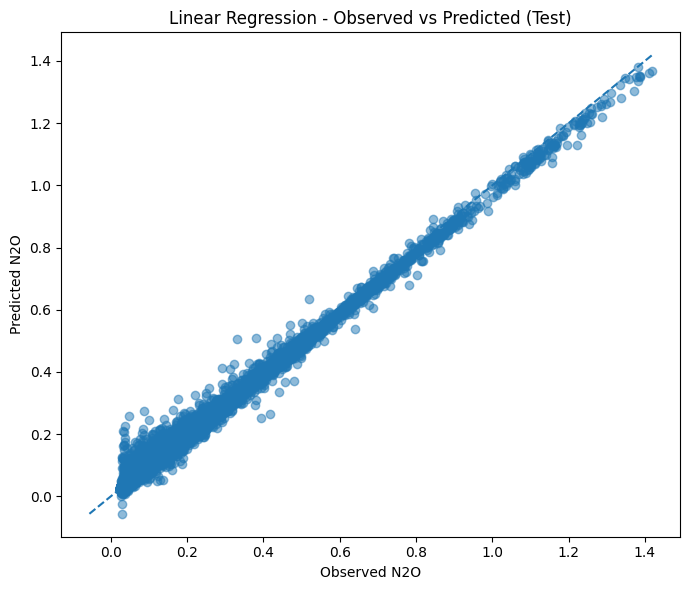

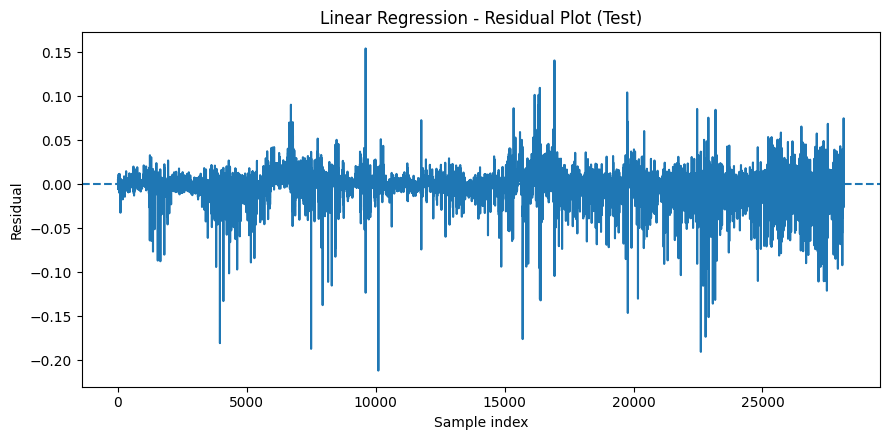

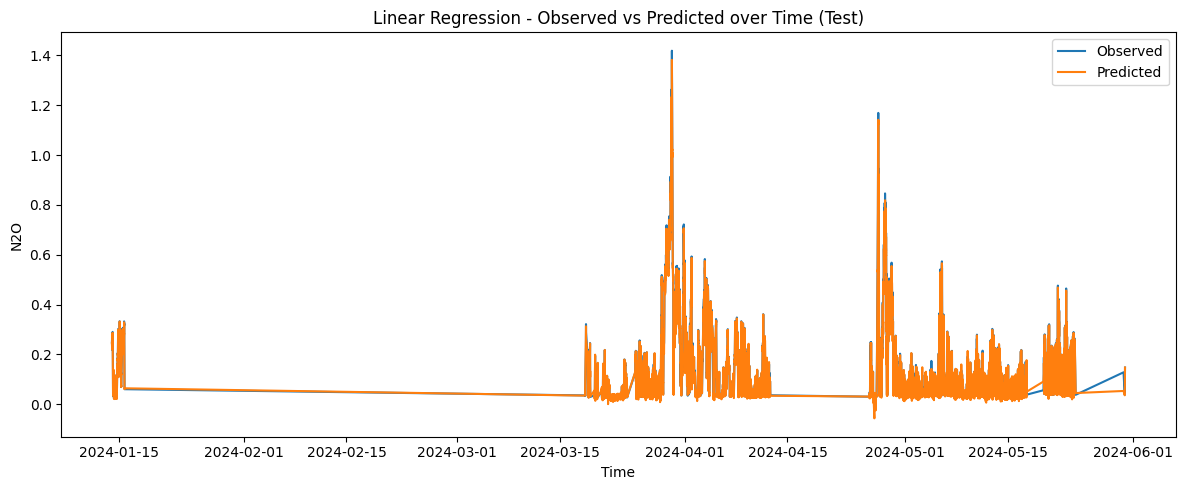

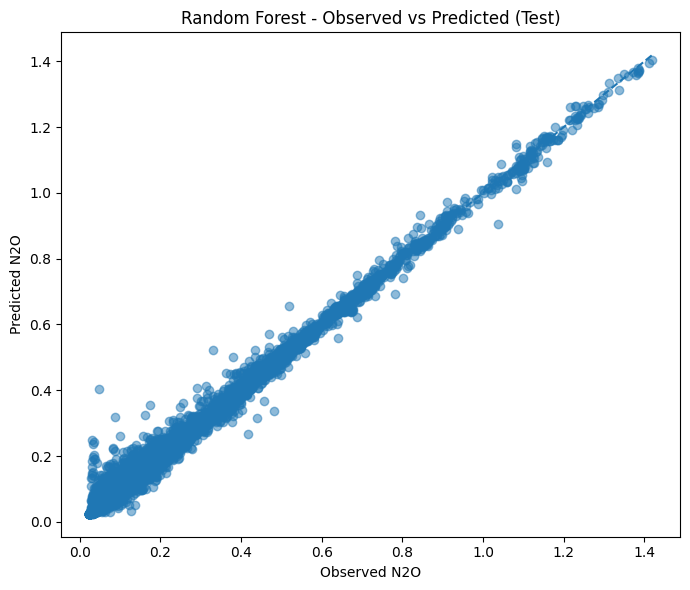

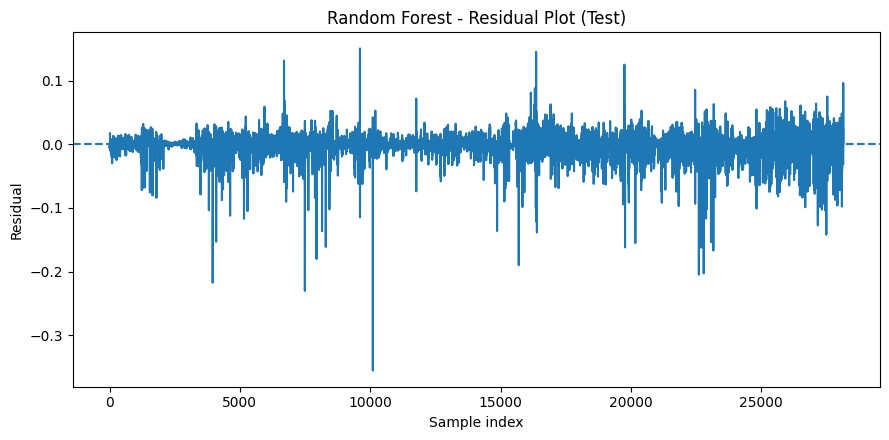

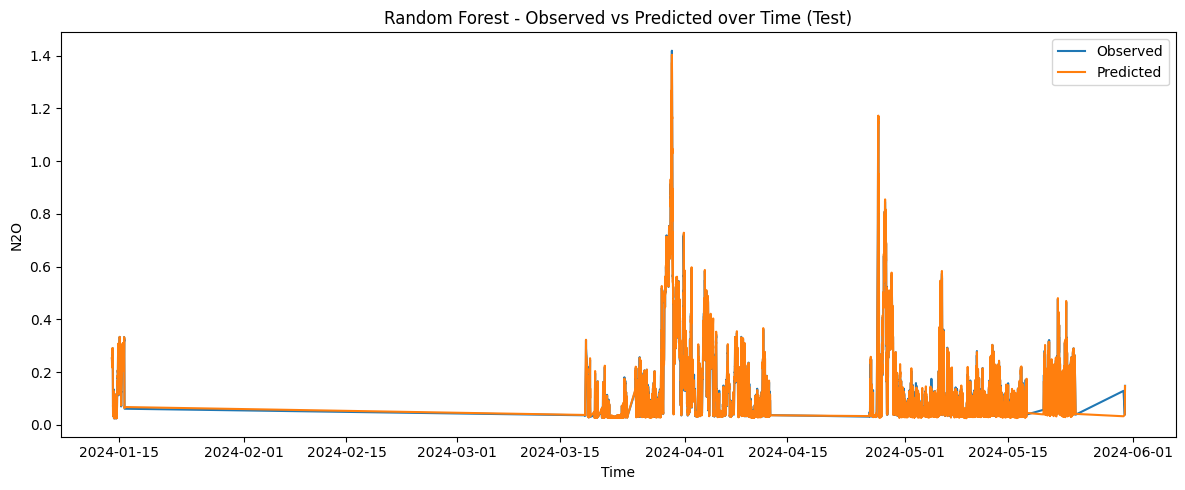

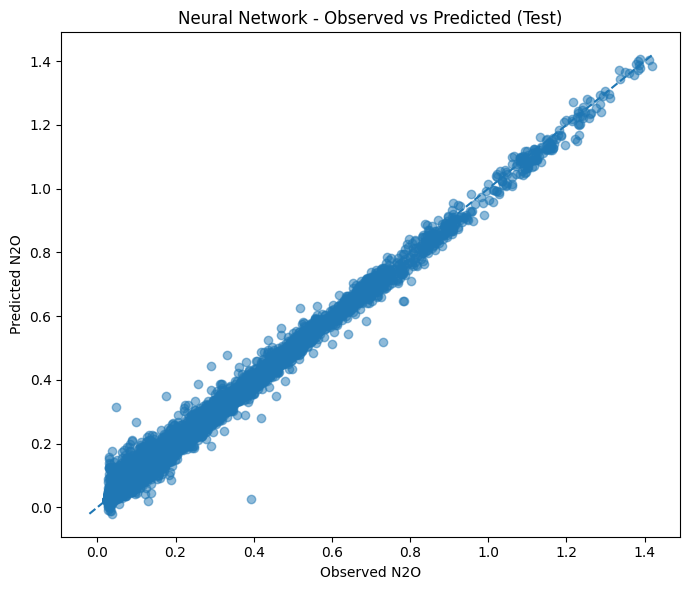

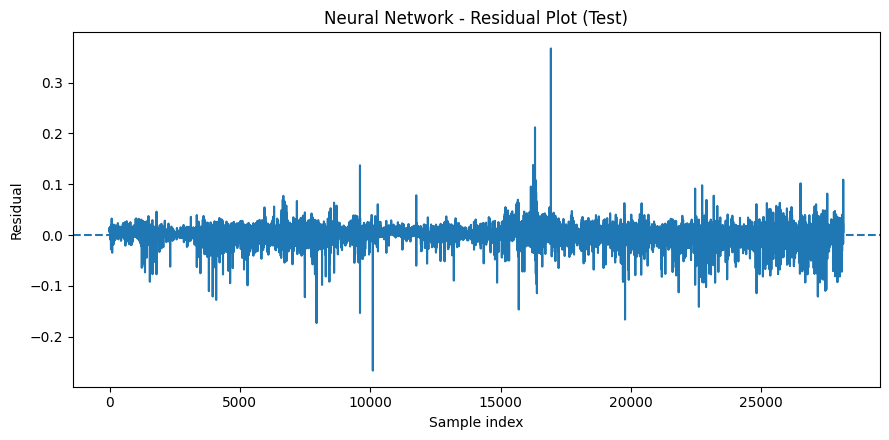

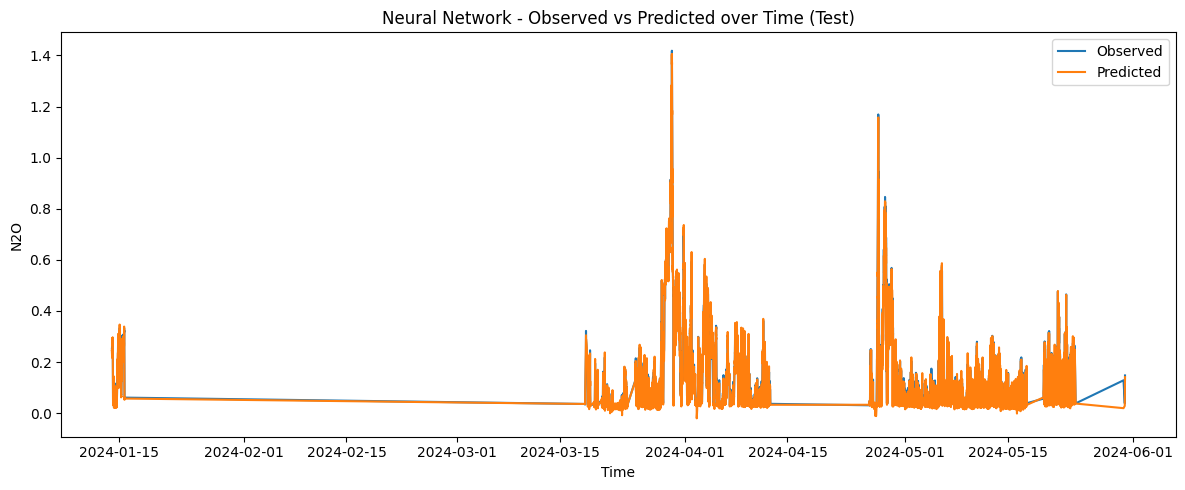


Validation predictions preview:
               Unnamed: 0   t1_n2o  pred_Linear Regression  pred_Random Forest  pred_Neural Network
2023-11-09 02:36:00+00:00 0.004630                0.009756            0.006842             0.013685
2023-11-09 02:38:00+00:00 0.004630                0.004070            0.005217             0.004459
2023-11-09 02:40:00+00:00 0.004630                0.007727            0.005226             0.010085
2023-11-09 02:42:00+00:00 0.004630                0.006919            0.005226             0.011355
2023-11-09 02:44:00+00:00 0.005787                0.011314            0.005219             0.014091

Test predictions preview:
               Unnamed: 0   t1_n2o  pred_Linear Regression  pred_Random Forest  pred_Neural Network
2024-01-14 02:08:00+00:00 0.251736                0.247175            0.254627             0.243829
2024-01-14 02:10:00+00:00 0.250000                0.249139            0.255252             0.243656
2024-01-14 02:12:00+00:00 0.249421      

In [23]:
# ============================================================
# MODEL SELECTION, DEVELOPMENT, AND EVALUATION FOR N2O
# Updated version:
# - only January, February, March data
# - only lag 1
# - no rolling features
# - only selected features:
#   nh4, no3, do, temp, ss, po4, airflow
# - only models:
#   Linear Regression, Random Forest, Neural Network
# - only metrics:
#   R2 and RMSE
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# ============================================================
# 1. USER SETTINGS
# ============================================================

FILE_PATH = "../../data/archive/df_clean.csv"
TIME_COL = "Unnamed: 0"
TARGET = "t1_n2o"

SELECTED_FEATURES = [
    "t1_nh4",
    "t1_no3",
    "inflow",
    "t1_temp",
    "t1_ss",
    "t1_po4",
    "t1_airflow"
]

GOOD_QUALITY_VALUE = 0

TRAIN_SIZE_FRACTION = 0.60
VALID_SIZE_FRACTION = 0.20
TEST_SIZE_FRACTION  = 0.20

RANDOM_STATE = 42

USE_LAG_FEATURES = True
LAG_STEPS = [1]

# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def safe_r2(y_true, y_pred):
    y_true = np.asarray(y_true)
    if len(y_true) < 2:
        return np.nan
    if np.isclose(np.var(y_true), 0):
        return np.nan
    return r2_score(y_true, y_pred)

def regression_metrics(y_true, y_pred, model_name="model", segment=""):
    return {
        "model": model_name,
        "segment": segment,
        "RMSE": rmse(y_true, y_pred),
        "R2": safe_r2(y_true, y_pred)
    }

def plot_observed_vs_predicted(y_true, y_pred, model_name, segment):
    plt.figure(figsize=(7, 6))
    plt.scatter(y_true, y_pred, alpha=0.5)
    mn = min(np.nanmin(y_true), np.nanmin(y_pred))
    mx = max(np.nanmax(y_true), np.nanmax(y_pred))
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Observed N2O")
    plt.ylabel("Predicted N2O")
    plt.title(f"{model_name} - Observed vs Predicted ({segment})")
    plt.tight_layout()
    plt.show()

def plot_residuals(y_true, y_pred, model_name, segment):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    plt.figure(figsize=(9, 4.5))
    plt.plot(residuals)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Sample index")
    plt.ylabel("Residual")
    plt.title(f"{model_name} - Residual Plot ({segment})")
    plt.tight_layout()
    plt.show()

def plot_timeseries(df_part, y_true, y_pred, time_col, model_name, segment):
    plt.figure(figsize=(12, 5))
    if time_col in df_part.columns:
        plt.plot(df_part[time_col], y_true.values, label="Observed")
        plt.plot(df_part[time_col], y_pred, label="Predicted")
        plt.xlabel("Time")
    else:
        plt.plot(y_true.values, label="Observed")
        plt.plot(y_pred, label="Predicted")
        plt.xlabel("Sample index")
    plt.ylabel("N2O")
    plt.title(f"{model_name} - Observed vs Predicted over Time ({segment})")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_metric_bar(results_df, metric, segment):
    ascending = metric != "R2"
    df_plot = results_df[results_df["segment"] == segment].sort_values(metric, ascending=ascending)

    plt.figure(figsize=(10, 5))
    plt.bar(df_plot["model"], df_plot[metric])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(metric)
    plt.title(f"{metric} Comparison Across Models ({segment})")
    plt.tight_layout()
    plt.show()

def plot_combined_timeseries(df_part, y_true, predictions_dict, time_col, segment):
    plt.figure(figsize=(14, 6))
    if time_col in df_part.columns:
        x = df_part[time_col]
        plt.plot(x, y_true.values, label="Observed", linewidth=2)
        for model_name, pred in predictions_dict.items():
            plt.plot(x, pred, label=model_name, alpha=0.8)
        plt.xlabel("Time")
    else:
        x = np.arange(len(y_true))
        plt.plot(x, y_true.values, label="Observed", linewidth=2)
        for model_name, pred in predictions_dict.items():
            plt.plot(x, pred, label=model_name, alpha=0.8)
        plt.xlabel("Sample index")

    plt.ylabel("N2O")
    plt.title(f"Observed vs All Model Predictions ({segment})")
    plt.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()

def plot_feature_importance(features, importances, model_name):
    fi_df = pd.DataFrame({
        "feature": features,
        "importance": importances
    }).sort_values("importance", ascending=True)

    plt.figure(figsize=(8, 6))
    plt.barh(fi_df["feature"], fi_df["importance"])
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.title(f"Feature Importance - {model_name}")
    plt.tight_layout()
    plt.show()

def plot_coefficients(features, coefficients, model_name):
    coef_df = pd.DataFrame({
        "feature": features,
        "coefficient": coefficients
    })
    coef_df["abs_coef"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coef", ascending=True)

    plt.figure(figsize=(8, 6))
    plt.barh(coef_df["feature"], coef_df["coefficient"])
    plt.xlabel("Coefficient")
    plt.ylabel("Feature")
    plt.title(f"Model Coefficients - {model_name}")
    plt.tight_layout()
    plt.show()

def add_time_features(df, base_features, target_col):
    df = df.copy()
    engineered = []

    cols_for_lagging = list(base_features) + [target_col]

    if USE_LAG_FEATURES:
        for col in cols_for_lagging:
            if col in df.columns:
                for lag in LAG_STEPS:
                    new_col = f"{col}_lag{lag}"
                    df[new_col] = df[col].shift(lag)
                    engineered.append(new_col)

    return df, engineered

# ============================================================
# 3. LOAD AND PREPARE DATA
# ============================================================

df = pd.read_csv(FILE_PATH)

if TIME_COL not in df.columns:
    raise ValueError(f"Time column '{TIME_COL}' not found in dataset.")

df[TIME_COL] = pd.to_datetime(df[TIME_COL], utc=True, errors="coerce")
df = df.sort_values(TIME_COL).reset_index(drop=True)

# Keep only January, February, March
#df = df[df[TIME_COL].dt.month.isin([1, 2, 3])].copy().reset_index(drop=True)

base_features = [c for c in SELECTED_FEATURES if c in df.columns]

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found in dataset.")

if len(base_features) == 0:
    raise ValueError("None of the selected features were found in the dataset.")

print("Target:", TARGET)
print("Base features used:", base_features)
#print("Months included:", sorted(df[TIME_COL].dt.month.dropna().unique().tolist()))

quality_cols_needed = [f"{TARGET}_q"] + [f"{f}_q" for f in base_features]
quality_cols_existing = [c for c in quality_cols_needed if c in df.columns]

if quality_cols_existing:
    mask_good = pd.Series(True, index=df.index)
    for qc in quality_cols_existing:
        mask_good &= (df[qc].fillna(GOOD_QUALITY_VALUE) == GOOD_QUALITY_VALUE)
    df_model = df.loc[mask_good].copy()
else:
    df_model = df.copy()

df_model, engineered_features = add_time_features(df_model, base_features, TARGET)

all_features = base_features + engineered_features

keep_cols = [TIME_COL, TARGET] + [c for c in all_features if c in df_model.columns]
df_model = df_model[keep_cols].copy()

df_model = df_model.dropna(subset=[TARGET]).reset_index(drop=True)
df_model = df_model.dropna(subset=[c for c in all_features if c in df_model.columns]).reset_index(drop=True)

features = [c for c in all_features if c in df_model.columns]

print("\nPrepared dataframe shape:", df_model.shape)
print("Total modelling features:", len(features))
print("Final feature list:")
print(features)

# ============================================================
# 4. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

n_total = len(df_model)
n_train = int(n_total * TRAIN_SIZE_FRACTION)
n_valid = int(n_total * VALID_SIZE_FRACTION)
n_test = n_total - n_train - n_valid

train_df = df_model.iloc[:n_train].copy()
valid_df = df_model.iloc[n_train:n_train + n_valid].copy()
test_df  = df_model.iloc[n_train + n_valid:].copy()

X_train = train_df[features]
y_train = train_df[TARGET]

X_valid = valid_df[features]
y_valid = valid_df[TARGET]

X_test = test_df[features]
y_test = test_df[TARGET]

print("\nTrain shape     :", X_train.shape, y_train.shape)
print("Validation shape:", X_valid.shape, y_valid.shape)
print("Test shape      :", X_test.shape, y_test.shape)

# ============================================================
# 5. MODELS
# ============================================================

models = {
    "Linear Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(
            n_estimators=400,
            max_depth=12,
            min_samples_split=4,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),

    "Neural Network": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", MLPRegressor(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=0.0001,
            batch_size="auto",
            learning_rate="adaptive",
            learning_rate_init=0.001,
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=20,
            random_state=RANDOM_STATE
        ))
    ])
}

# ============================================================
# 6. VALIDATION RESULTS
# ============================================================

validation_results = []
validation_predictions = {}

print("\n" + "="*90)
print("VALIDATION RESULTS FOR ALL MODELS")
print("="*90)

for model_name, model in models.items():
    model.fit(X_train, y_train)
    pred_valid = model.predict(X_valid)
    validation_predictions[model_name] = pred_valid

    metrics = regression_metrics(y_valid, pred_valid, model_name=model_name, segment="validation")
    validation_results.append(metrics)

validation_results_df = pd.DataFrame(validation_results).sort_values("RMSE").reset_index(drop=True)
print(validation_results_df.to_string(index=False))

# ============================================================
# 7. BEST MODEL FROM VALIDATION
# ============================================================

best_validation_row = validation_results_df.iloc[0]
best_model_name = best_validation_row["model"]
print("\nBest model on validation RMSE:", best_model_name)

# ============================================================
# 8. RETRAIN ON TRAIN + VALIDATION, TEST ON TEST
# ============================================================

train_valid_df = pd.concat([train_df, valid_df], axis=0).reset_index(drop=True)
X_train_valid = train_valid_df[features]
y_train_valid = train_valid_df[TARGET]

test_results = []
test_predictions = {}
trained_models = {}

print("\n" + "="*90)
print("TEST RESULTS FOR ALL MODELS")
print("="*90)

for model_name, model in models.items():
    model.fit(X_train_valid, y_train_valid)
    trained_models[model_name] = model

    pred_test = model.predict(X_test)
    test_predictions[model_name] = pred_test

    metrics = regression_metrics(y_test, pred_test, model_name=model_name, segment="test")
    test_results.append(metrics)

test_results_df = pd.DataFrame(test_results).sort_values("RMSE").reset_index(drop=True)
print(test_results_df.to_string(index=False))

# ============================================================
# 9. SUMMARY TABLE
# ============================================================

summary_results_df = pd.concat([validation_results_df, test_results_df], ignore_index=True)

print("\n" + "="*90)
print("SUMMARY RESULTS")
print("="*90)
print(summary_results_df.to_string(index=False))

# ============================================================
# 10. PLOTS - VALIDATION
# ============================================================

plot_metric_bar(validation_results_df, "RMSE", "validation")
plot_metric_bar(validation_results_df, "R2", "validation")
plot_combined_timeseries(valid_df, y_valid, validation_predictions, TIME_COL, "Validation")

for model_name, pred_valid in validation_predictions.items():
    plot_observed_vs_predicted(y_valid, pred_valid, model_name, "Validation")
    plot_residuals(y_valid, pred_valid, model_name, "Validation")
    plot_timeseries(valid_df, y_valid, pred_valid, TIME_COL, model_name, "Validation")

# ============================================================
# 11. PLOTS - TEST
# ============================================================

plot_metric_bar(test_results_df, "RMSE", "test")
plot_metric_bar(test_results_df, "R2", "test")
plot_combined_timeseries(test_df, y_test, test_predictions, TIME_COL, "Test")

for model_name, pred_test in test_predictions.items():
    plot_observed_vs_predicted(y_test, pred_test, model_name, "Test")
    plot_residuals(y_test, pred_test, model_name, "Test")
    plot_timeseries(test_df, y_test, pred_test, TIME_COL, model_name, "Test")

# ============================================================
# 12. INTERPRET THE BEST MODEL
# ============================================================

best_model = trained_models[best_model_name]

if hasattr(best_model, "named_steps") and "model" in best_model.named_steps:
    inner_model = best_model.named_steps["model"]

    if hasattr(inner_model, "coef_"):
        coef_df = pd.DataFrame({
            "feature": features,
            "coefficient": inner_model.coef_
        }).sort_values("coefficient", key=np.abs, ascending=False)

        print("\nTop coefficients for best model:")
        print(coef_df.head(20).to_string(index=False))

        plot_coefficients(features, inner_model.coef_, best_model_name)

    if hasattr(inner_model, "feature_importances_"):
        fi_df = pd.DataFrame({
            "feature": features,
            "importance": inner_model.feature_importances_
        }).sort_values("importance", ascending=False)

        print("\nTop feature importances for best model:")
        print(fi_df.head(20).to_string(index=False))

        plot_feature_importance(features, inner_model.feature_importances_, best_model_name)

# ============================================================
# 13. OPTIONAL: SHOW ACTUAL PREDICTION TABLES
# ============================================================

validation_pred_df = valid_df[[TIME_COL, TARGET]].copy()
for model_name, pred in validation_predictions.items():
    validation_pred_df[f"pred_{model_name}"] = pred

test_pred_df = test_df[[TIME_COL, TARGET]].copy()
for model_name, pred in test_predictions.items():
    test_pred_df[f"pred_{model_name}"] = pred

print("\nValidation predictions preview:")
print(validation_pred_df.head().to_string(index=False))

print("\nTest predictions preview:")
print(test_pred_df.head().to_string(index=False))

# ============================================================
# 14. SAVE THE BEST MODEL FOR FUTURE USE
# ============================================================

print("\nSaving the best model for future use...")

best_model = trained_models[best_model_name]
best_model.fit(X_train_valid, y_train_valid)

model_filename = "best_n2o_model.pkl"
features_filename = "model_features.pkl"

joblib.dump(best_model, model_filename)
joblib.dump(features, features_filename)

print(f"\nBest model saved as: {model_filename}")
print(f"Feature list saved as: {features_filename}")
print("You can reload this model later for prediction.")

Loaded model: <class 'sklearn.pipeline.Pipeline'>
Number of expected features: 15

Raw data shape: (906815, 49)

Prediction complete.
Output saved to: aved_raw_predictions.csv

Preview:
                     time   t1_n2o  predicted_t1_n2o  t1_nh4   t1_no3  t1_airflow  t1_temp    t1_ss   t1_po4  inflow
2022-06-11 22:01:00+00:00 0.700231          0.013697 1.66608 0.074907         NaN      NaN 1.525374 0.285834     NaN
2022-06-11 22:02:00+00:00      NaN          0.704459     NaN      NaN         NaN      NaN      NaN      NaN     NaN
2022-06-11 22:03:00+00:00 0.697917          0.014119 1.52727 0.074907         NaN      NaN 1.536805 0.273499     NaN
2022-06-11 22:04:00+00:00      NaN          0.695755     NaN      NaN         NaN      NaN      NaN      NaN     NaN
2022-06-11 22:05:00+00:00 0.656829          0.014646 1.43633 0.056901         NaN      NaN 1.509847 0.273499     NaN
2022-06-11 22:06:00+00:00      NaN          0.630100     NaN      NaN         NaN      NaN      NaN      NaN    

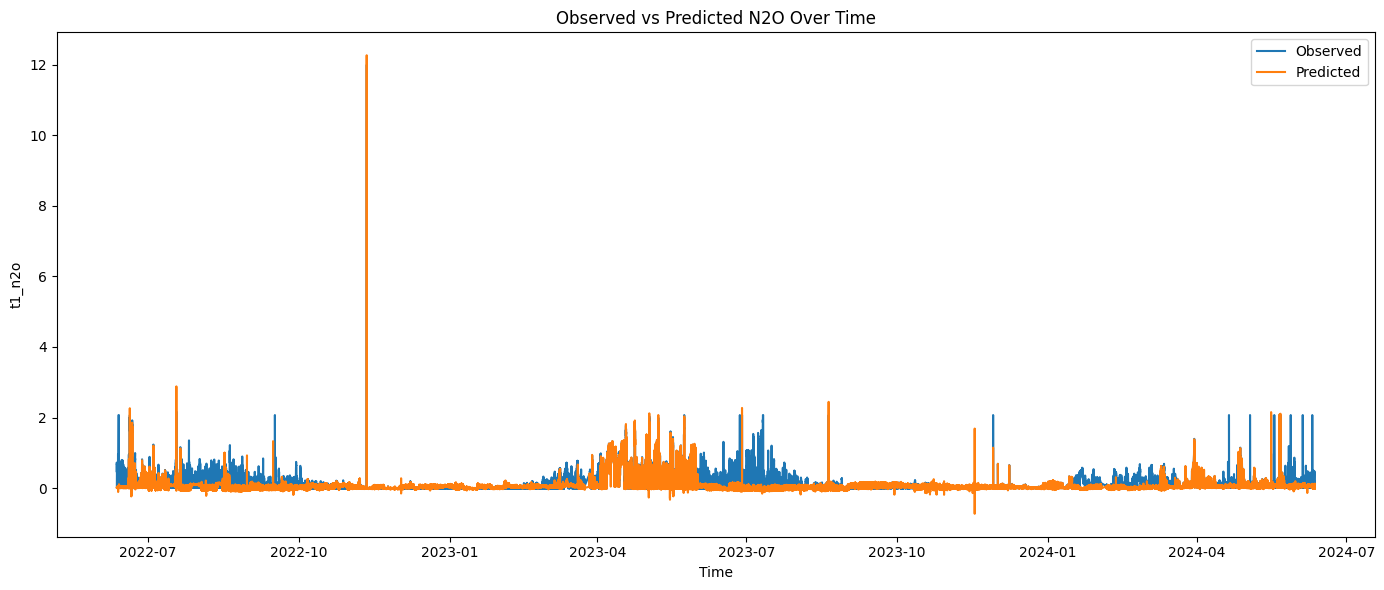

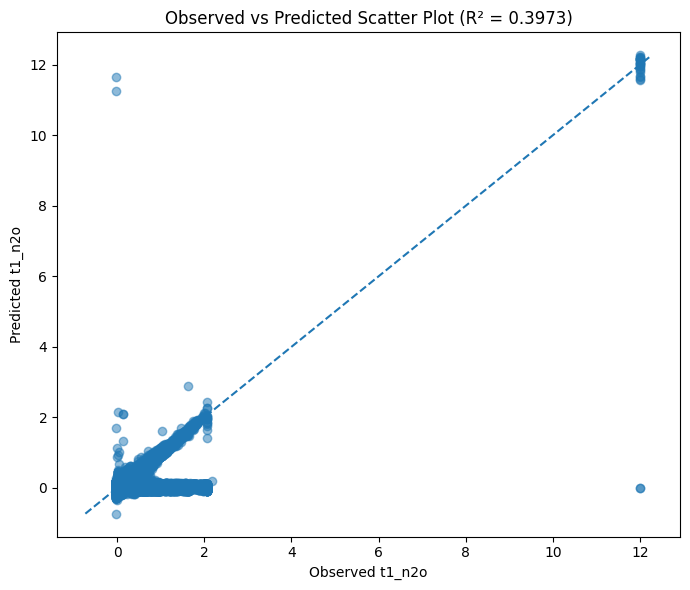

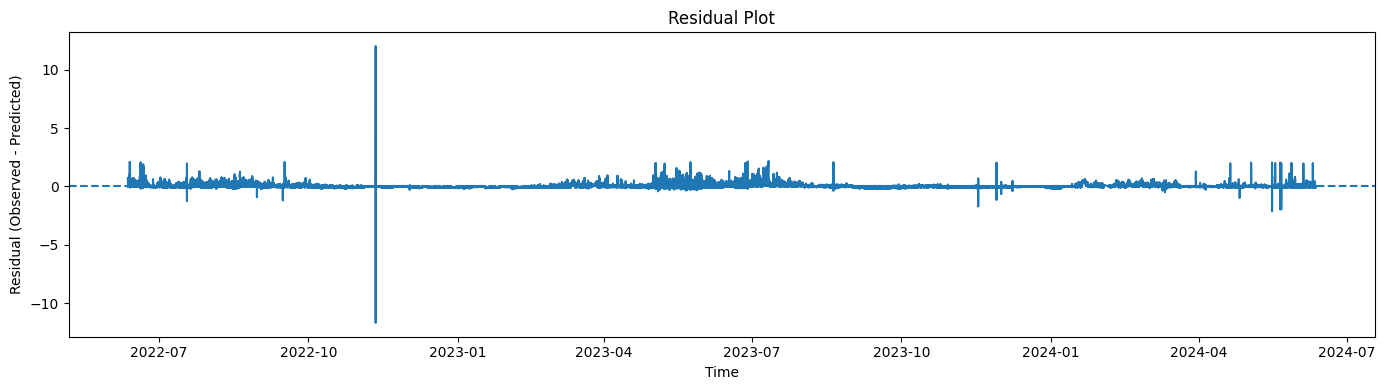

In [24]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ============================================================
# 1. FILES
# ============================================================

MODEL_PATH = "best_n2o_model.pkl"
FEATURES_PATH = "model_features.pkl"
DATA_PATH = "aved_raw.csv"
OUTPUT_PATH = "aved_raw_predictions.csv"

TIME_COL = "time"

# ============================================================
# 2. LOAD MODEL AND EXPECTED FEATURES
# ============================================================

model = joblib.load(MODEL_PATH)
expected_features = joblib.load(FEATURES_PATH)

print("Loaded model:", type(model))
print("Number of expected features:", len(expected_features))

# ============================================================
# 3. LOAD RAW DATA
# ============================================================

df_raw = pd.read_csv(DATA_PATH)
df_raw[TIME_COL] = pd.to_datetime(df_raw[TIME_COL], errors="coerce", utc=True)
df_raw = df_raw.sort_values(TIME_COL).reset_index(drop=True)

print("\nRaw data shape:", df_raw.shape)

# ============================================================
# 4. MAP RAW COLUMNS TO TRAINING NAMES
# ============================================================

rename_map = {
    "BIOLOGY.LINE 3 TANK 1.NH4 value": "t1_nh4",
    "BIOLOGY.LINE 3 TANK 1.NO3 value": "t1_no3",
    "BIOLOGY.LINE 3 TANK 1.O2 value": "t1_do",
    "BIOLOGY.LINE 3 TANK 1.Q.AIRFLOW value": "t1_airflow",
    "BIOLOGY.LINE 3 TANK 1.TEMPERATURE value": "t1_temp",
    "BIOLOGY.LINE 3 TANK 1.O2.SETPOINT value": "t1_do_sp",
    "BIOLOGY.LINE 3 TANK 1.SS value": "t1_ss",
    "BIOLOGY.LINE 3 TANK 1.PO4 value": "t1_po4",
    "INLET.Q value": "inflow",
    "BIOLOGY.LINE 3 TANK 1.N2O value": "t1_n2o"
}

df = df_raw.rename(columns=rename_map).copy()

# ============================================================
# 5. BASE FEATURES
# ============================================================

base_features = [
    "t1_nh4",
    "t1_no3",
    "t1_airflow",
    "t1_temp",
    "t1_ss",
    "t1_po4",
    "inflow",
]

target_col = "t1_n2o"

missing_base = [c for c in base_features + [target_col] if c not in df.columns]
if missing_base:
    raise ValueError(f"Missing required columns after renaming: {missing_base}")

# ============================================================
# 6. RECREATE TRAINING-TIME FEATURE ENGINEERING
# ============================================================

LAG_STEPS = [1, 3, 6, 12]
ROLL_WINDOWS = [3, 6, 12]

def add_time_features(dataframe, base_features, target_col):
    dataframe = dataframe.copy()
    engineered = []

    cols_for_lagging = list(base_features) + [target_col]

    for col in cols_for_lagging:
        for lag in LAG_STEPS:
            new_col = f"{col}_lag{lag}"
            dataframe[new_col] = dataframe[col].shift(lag)
            engineered.append(new_col)

    for col in cols_for_lagging:
        for win in ROLL_WINDOWS:
            mean_col = f"{col}_rollmean{win}"
            std_col = f"{col}_rollstd{win}"

            dataframe[mean_col] = dataframe[col].shift(1).rolling(win).mean()
            dataframe[std_col] = dataframe[col].shift(1).rolling(win).std()

            engineered.extend([mean_col, std_col])

    return dataframe, engineered

df_feat, engineered_features = add_time_features(df, base_features, target_col)

# ============================================================
# 7. BUILD MODEL INPUT IN EXACT FEATURE ORDER
# ============================================================

for col in expected_features:
    if col not in df_feat.columns:
        df_feat[col] = np.nan

X = df_feat[expected_features].copy()

# Predict only rows with enough information
predictable_mask = ~X.isna().all(axis=1)

if predictable_mask.sum() == 0:
    raise ValueError("No rows available for prediction after feature engineering.")

predictions = np.full(len(df_feat), np.nan)
predictions[predictable_mask] = model.predict(X.loc[predictable_mask])

df_feat["predicted_t1_n2o"] = predictions

# ============================================================
# 8. OUTPUT TABLE
# ============================================================

result_cols = [TIME_COL]
for col in ["t1_n2o", "predicted_t1_n2o"] + base_features:
    if col in df_feat.columns:
        result_cols.append(col)

results = df_feat[result_cols].copy()
#results.to_csv(OUTPUT_PATH, index=False)

print("\nPrediction complete.")
print("Output saved to:", OUTPUT_PATH)
print("\nPreview:")
print(results.head(20).to_string(index=False))

# ============================================================
# 9. CALCULATE R2 AND OTHER METRICS
# ============================================================

eval_df = results.dropna(subset=["t1_n2o", "predicted_t1_n2o"]).copy()

if len(eval_df) < 2:
    print("\nNot enough valid rows to calculate R².")
else:
    y_true = eval_df["t1_n2o"].values
    y_pred = eval_df["predicted_t1_n2o"].values

    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    print("\nModel evaluation on available observed values:")
    print(f"R²   = {r2:.4f}")
    print(f"MAE  = {mae:.4f}")
    print(f"RMSE = {rmse:.4f}")
    print(f"Rows used for evaluation: {len(eval_df)}")

    # ========================================================
    # 10. PLOT OBSERVED VS PREDICTED OVER TIME
    # ========================================================

    plt.figure(figsize=(14, 6))
    plt.plot(eval_df[TIME_COL], eval_df["t1_n2o"], label="Observed")
    plt.plot(eval_df[TIME_COL], eval_df["predicted_t1_n2o"], label="Predicted")
    plt.xlabel("Time")
    plt.ylabel("t1_n2o")
    plt.title("Observed vs Predicted N2O Over Time")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ========================================================
    # 11. SCATTER PLOT: OBSERVED VS PREDICTED
    # ========================================================

    plt.figure(figsize=(7, 6))
    plt.scatter(eval_df["t1_n2o"], eval_df["predicted_t1_n2o"], alpha=0.5)
    mn = min(eval_df["t1_n2o"].min(), eval_df["predicted_t1_n2o"].min())
    mx = max(eval_df["t1_n2o"].max(), eval_df["predicted_t1_n2o"].max())
    plt.plot([mn, mx], [mn, mx], linestyle="--")
    plt.xlabel("Observed t1_n2o")
    plt.ylabel("Predicted t1_n2o")
    plt.title(f"Observed vs Predicted Scatter Plot (R² = {r2:.4f})")
    plt.tight_layout()
    plt.show()

    # ========================================================
    # 12. RESIDUAL PLOT
    # ========================================================

    residuals = eval_df["t1_n2o"] - eval_df["predicted_t1_n2o"]

    plt.figure(figsize=(14, 4))
    plt.plot(eval_df[TIME_COL], residuals)
    plt.axhline(0, linestyle="--")
    plt.xlabel("Time")
    plt.ylabel("Residual (Observed - Predicted)")
    plt.title("Residual Plot")
    plt.tight_layout()
    plt.show()